Iter  1 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  2 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  3 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  4 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  5 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  6 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  7 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  8 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter  9 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter 10 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter 11 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00
Iter 12 | u1(γ)=0.00000 | u2(γ)=0.00000 | exact(γ)=0.10132 | gap=0.00e+00

Rel. L2 = 1.3016e+00


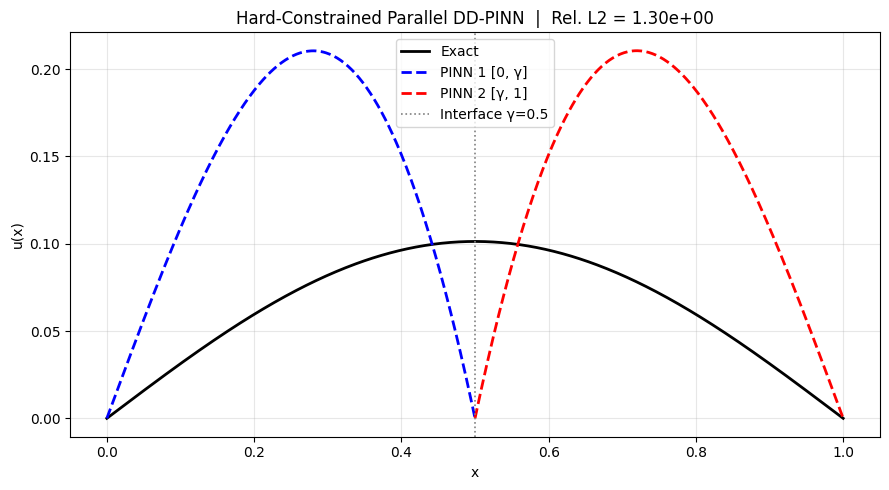

In [11]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from concurrent.futures import ThreadPoolExecutor
import threading

torch.manual_seed(42)

# ==========================================
# 1. HARD-CONSTRAINED PINN
# ==========================================
class HardPINN(nn.Module):
    """
    Hard boundary enforcement via distance functions.
    
    For subdomain [a, b] with u(a)=ua, u(b)=ub:
        u(x) = ua + (x-a)/(b-a) * (ub - ua)   <- linear lift (satisfies BCs exactly)
               + (x-a)(x-b) * net(x)            <- homogeneous correction (zero at a,b)
    
    Both outer BCs AND interface BC are baked in — no penalty terms at all.
    """
    def __init__(self, a, b, hidden_layers=4, neurons=64):
        super().__init__()
        self.a = a
        self.b = b
        # Learnable BCs: outer BCs are fixed, interface BC is passed at forward time
        self.net = nn.Sequential(
            nn.Linear(1, neurons), nn.Tanh(),
            *[l for _ in range(hidden_layers - 1)
              for l in (nn.Linear(neurons, neurons), nn.Tanh())],
            nn.Linear(neurons, 1)
        )
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, ua, ub):
        """
        x  : (N,1) collocation points in [a, b]
        ua : scalar tensor — value at left endpoint
        ub : scalar tensor — value at right endpoint
        """
        a, b = self.a, self.b
        # Linear lift: satisfies u(a)=ua, u(b)=ub exactly
        lift = ua + (x - a) / (b - a) * (ub - ua)
        # Distance function: zero at both endpoints
        D = (x - a) * (x - b)
        return lift + D * self.net(x)


def compute_derivatives(u, x):
    du = torch.autograd.grad(u, x, grad_outputs=torch.ones_like(u),
                              create_graph=True)[0]
    d2u = torch.autograd.grad(du, x, grad_outputs=torch.ones_like(du),
                               create_graph=True)[0]
    return du, d2u


# ==========================================
# 2. TRAINING (PDE loss only — no BC penalty)
# ==========================================
def train_one_iter(model, optimizer, x_col, ua, ub, f_func, epochs):
    model.train()
    for _ in range(epochs):
        optimizer.zero_grad()
        u = model(x_col, ua, ub)
        _, u_xx = compute_derivatives(u, x_col)
        # Only PDE residual — BCs are hard-enforced, no penalty needed
        loss = torch.mean((u_xx + f_func(x_col)) ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
    return model


# ==========================================
# 3. PROBLEM
# ==========================================
def f_func(x):
    return (torch.pi ** 2) * torch.sin(torch.pi * x)

def exact(x):
    return torch.sin(torch.pi * x) / (torch.pi ** 2)


# ==========================================
# 4. PARALLEL DOMAIN DECOMPOSITION
# ==========================================
def parallel_dd(gamma=0.5, n_iter=12, epochs_per_iter=3000, lr=1e-3, alpha=0.5):
    """
    Parallel Schwarz with hard BCs (Dirichlet-Dirichlet at interface).
    
    pinn1: [0, gamma],  u(0)=0,     u(gamma) = u2_iface  (from pinn2 prev iter)
    pinn2: [gamma, 1],  u(gamma) = u1_iface  (from pinn1 prev iter),  u(1)=0
    
    Interface exchange: relaxed Jacobi  u_new = alpha*u_current + (1-alpha)*u_old
    No penalty terms anywhere.
    """
    pinn1 = HardPINN(a=0.0,   b=gamma)
    pinn2 = HardPINN(a=gamma, b=1.0)
    opt1  = torch.optim.Adam(pinn1.parameters(), lr=lr)
    opt2  = torch.optim.Adam(pinn2.parameters(), lr=lr)
    sched1 = torch.optim.lr_scheduler.CosineAnnealingLR(opt1, T_max=n_iter, eta_min=1e-4)
    sched2 = torch.optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=n_iter, eta_min=1e-4)

    x1_col = torch.linspace(0,     gamma, 200).view(-1, 1).requires_grad_(True)
    x2_col = torch.linspace(gamma, 1,     200).view(-1, 1).requires_grad_(True)

    x_iface = torch.tensor([[gamma]])

    # Outer BCs (fixed, hard-enforced)
    u_left  = torch.tensor([[0.0]])
    u_right = torch.tensor([[0.0]])

    # Interface values — start from zero, converge via iteration
    u1_iface = torch.tensor([[0.0]])  # pinn1's u(gamma) → pinn2's left BC
    u2_iface = torch.tensor([[0.0]])  # pinn2's u(gamma) → pinn1's right BC

    lock = threading.Lock()

    for i in range(n_iter):
        with lock:
            snap_u1 = u1_iface.clone().detach()
            snap_u2 = u2_iface.clone().detach()

        # pinn1: u(0)=0, u(gamma)=snap_u2  (uses pinn2's interface value)
        # pinn2: u(gamma)=snap_u1, u(1)=0  (uses pinn1's interface value)
        def train1(su2=snap_u2):
            train_one_iter(pinn1, opt1, x1_col,
                           ua=u_left, ub=su2,
                           f_func=f_func, epochs=epochs_per_iter)

        def train2(su1=snap_u1):
            train_one_iter(pinn2, opt2, x2_col,
                           ua=su1, ub=u_right,
                           f_func=f_func, epochs=epochs_per_iter)

        with ThreadPoolExecutor(max_workers=2) as pool:
            f1 = pool.submit(train1)
            f2 = pool.submit(train2)
            f1.result(); f2.result()

        sched1.step(); sched2.step()

        # Extract new interface values
        with torch.no_grad():
            new_u1 = pinn1(x_iface, ua=u_left,   ub=snap_u2)
            new_u2 = pinn2(x_iface, ua=snap_u1,  ub=u_right)

        # Relaxed update
        with lock:
            u1_iface = alpha * new_u1 + (1 - alpha) * u1_iface
            u2_iface = alpha * new_u2 + (1 - alpha) * u2_iface

        gap = abs(new_u1.item() - new_u2.item())
        print(f"Iter {i+1:2d} | u1(γ)={new_u1.item():.5f} | "
              f"u2(γ)={new_u2.item():.5f} | "
              f"exact(γ)={exact(x_iface).item():.5f} | gap={gap:.2e}")

    return pinn1, pinn2, u1_iface, u2_iface


# ==========================================
# 5. RUN & PLOT
# ==========================================
pinn1, pinn2, u1_if, u2_if = parallel_dd(
    gamma=0.5, n_iter=12, epochs_per_iter=3000, lr=1e-3, alpha=0.5
)

pinn1.eval(); pinn2.eval()
gamma = 0.5

x1 = torch.linspace(0,     gamma, 300).view(-1, 1)
x2 = torch.linspace(gamma, 1,     300).view(-1, 1)

u_left  = torch.tensor([[0.0]])
u_right = torch.tensor([[0.0]])

with torch.no_grad():
    u1 = pinn1(x1, ua=u_left,  ub=u2_if).numpy()
    u2 = pinn2(x2, ua=u1_if,   ub=u_right).numpy()
    u_ex = exact(torch.cat([x1, x2])).numpy()

u_pred = np.concatenate([u1, u2])
l2 = np.sqrt(np.mean((u_pred - u_ex)**2)) / np.sqrt(np.mean(u_ex**2))
print(f"\nRel. L2 = {l2:.4e}")

plt.figure(figsize=(9, 5))
plt.plot(np.concatenate([x1.numpy(), x2.numpy()]), u_ex, 'k-', lw=2, label='Exact')
plt.plot(x1.numpy(), u1, 'b--', lw=2, label='PINN 1 [0, γ]')
plt.plot(x2.numpy(), u2, 'r--', lw=2, label='PINN 2 [γ, 1]')
plt.axvline(gamma, color='gray', ls=':', lw=1.2, label='Interface γ=0.5')
plt.title(f'Hard-Constrained Parallel DD-PINN  |  Rel. L2 = {l2:.2e}')
plt.xlabel('x'); plt.ylabel('u(x)')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout()
plt.savefig('hard_dd_pinn.png', dpi=150)
plt.show()

In [8]:
# ==========================================
# 2. TEST EQUATIONS (-u'' = f(x))
# ==========================================
# Equation 1: Baseline Sine
def pde_sine(x): return (torch.pi**2) * torch.sin(torch.pi * x)
def exact_sine(x): return torch.sin(torch.pi * x)

# Equation 2: Polynomial
def pde_poly(x): return torch.full_like(x, 2.0)
def exact_poly(x): return x - (x**2)

# Equation 3: Exponential
def pde_exp(x): return -torch.exp(x)
def exact_exp(x): 
    e = torch.exp(torch.tensor(1.0))
    return torch.exp(x) - x * (e - 1.0) - 1.0

# Equation 4: High-Frequency (Stress Test)
def pde_high_freq(x): return 16.0 * (torch.pi**2) * torch.sin(4.0 * torch.pi * x)
def exact_high_freq(x): return torch.sin(4.0 * torch.pi * x)


In [9]:
# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # CHOOSE YOUR EQUATION HERE:
    # Options: pde_sine, pde_poly, pde_exp, pde_high_freq
    active_pde = pde_sine
    active_exact = exact_sine
    
    print("Starting Dirichlet-Neumann Training...")
    
    # Run the orchestrator
    # If the subdomains don't stitch well, try increasing lambda_interface to 50.0
    model1, model2 = dirichlet_neumann_dd_loop(
        pde_func=active_pde, 
        gamma=0.5, 
        iterations=6, 
        epochs_per_iter=1500,
        lambda_interface=10.0
    )
    
    print("Training complete. Plotting...")
    plot_results(model1, model2, active_exact)

Starting Dirichlet-Neumann Training...
Iteration 1/6...


/var/folders/xy/b5kwft7572392kjr5nf85tkh0000gn/T/ipykernel_15117/2562895501.py:125: SyntaxWarning: "\g" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\g"? A raw string is also an option.
  plt.axvline(x=gamma, color='gray', linestyle=':', label='Interface ($\gamma$)')


TypeError: train_subdomain() missing 1 required positional argument: 'lambda_iface'

In [10]:
# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # CHOOSE YOUR EQUATION HERE:
    # Options: pde_sine, pde_poly, pde_exp, pde_high_freq
    active_pde = pde_poly
    active_exact = exact_poly
    
    print("Starting Dirichlet-Neumann Training...")
    
    # Run the orchestrator
    # If the subdomains don't stitch well, try increasing lambda_interface to 50.0
    model1, model2 = dirichlet_neumann_dd_loop(
        pde_func=active_pde, 
        gamma=0.5, 
        iterations=6, 
        epochs_per_iter=1500,
        lambda_interface=10.0
    )
    
    print("Training complete. Plotting...")
    plot_results(model1, model2, active_exact)

Starting Dirichlet-Neumann Training...
Iteration 1/6...


TypeError: train_subdomain() missing 1 required positional argument: 'lambda_iface'

Starting Dirichlet-Neumann Training...
Iteration 1/6...
Iteration 2/6...
Iteration 3/6...
Iteration 4/6...
Iteration 5/6...
Iteration 6/6...
Training complete. Plotting...


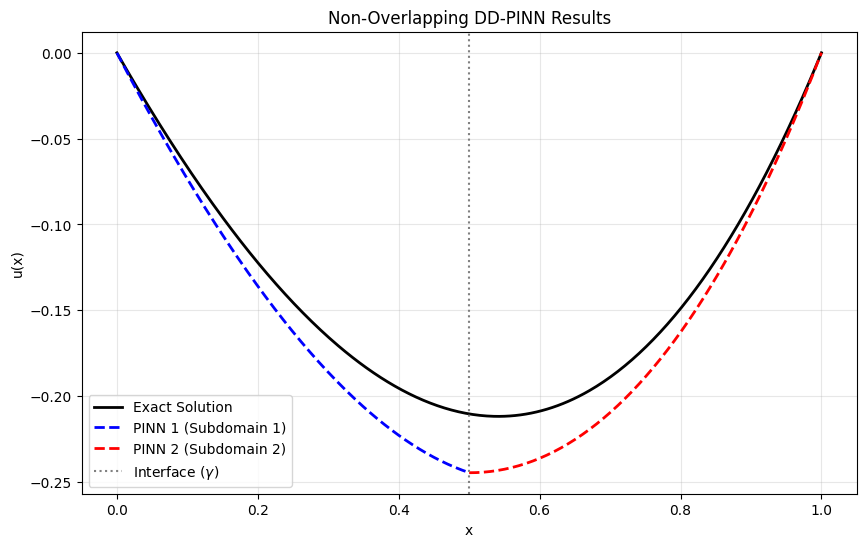

In [5]:
# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # CHOOSE YOUR EQUATION HERE:
    # Options: pde_sine, pde_poly, pde_exp, pde_high_freq
    active_pde = pde_exp
    active_exact = exact_exp
    
    print("Starting Dirichlet-Neumann Training...")
    
    # Run the orchestrator
    # If the subdomains don't stitch well, try increasing lambda_interface to 50.0
    model1, model2 = dirichlet_neumann_dd_loop(
        pde_func=active_pde, 
        gamma=0.5, 
        iterations=6, 
        epochs_per_iter=1500,
        lambda_interface=10.0
    )
    
    print("Training complete. Plotting...")
    plot_results(model1, model2, active_exact)

Starting Dirichlet-Neumann Training...
Iteration 1/6...
Iteration 2/6...
Iteration 3/6...
Iteration 4/6...
Iteration 5/6...
Iteration 6/6...
Training complete. Plotting...


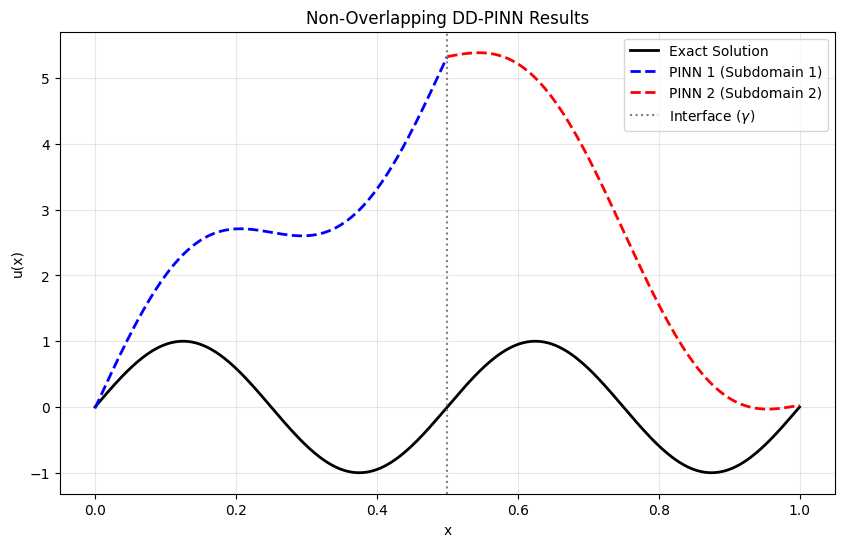

In [6]:
# ==========================================
# 5. MAIN EXECUTION
# ==========================================
if __name__ == "__main__":
    # CHOOSE YOUR EQUATION HERE:
    # Options: pde_sine, pde_poly, pde_exp, pde_high_freq
    active_pde = pde_high_freq
    active_exact = exact_high_freq
    
    print("Starting Dirichlet-Neumann Training...")
    
    # Run the orchestrator
    # If the subdomains don't stitch well, try increasing lambda_interface to 50.0
    model1, model2 = dirichlet_neumann_dd_loop(
        pde_func=active_pde, 
        gamma=0.5, 
        iterations=6, 
        epochs_per_iter=1500,
        lambda_interface=10.0
    )
    
    print("Training complete. Plotting...")
    plot_results(model1, model2, active_exact)